In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

/home/student/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

print(df.head())
print("Shape:", df.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  
Shape: (150, 5)


In [3]:
y_binary = np.where(y == 0, 0, 1)

print("Setosa:", np.sum(y_binary == 0))
print("Non-Setosa:", np.sum(y_binary == 1))

Setosa: 50
Non-Setosa: 100


In [4]:
X_binary = X[:, [0, 1]]

print("Selected features:")
print(iris.feature_names[0])
print(iris.feature_names[1])

Selected features:
sepal length (cm)
sepal width (cm)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
svm_model = SVC(
    kernel="linear",
    C=1.0
)

svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [8]:
y_pred = svm_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred)

Predictions:
[1 1 1 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 0 1 1 0 0 1 1 1 1 1 1]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Setosa", "Non-Setosa"]
))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Non-Setosa       1.00      1.00      1.00        20

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [10]:
w = svm_model.coef_[0]
b = svm_model.intercept_[0]

print("Weights:", w)
print("Bias:", b)

Weights: [ 2.05101145 -1.46627179]
Bias: 1.368845413320812


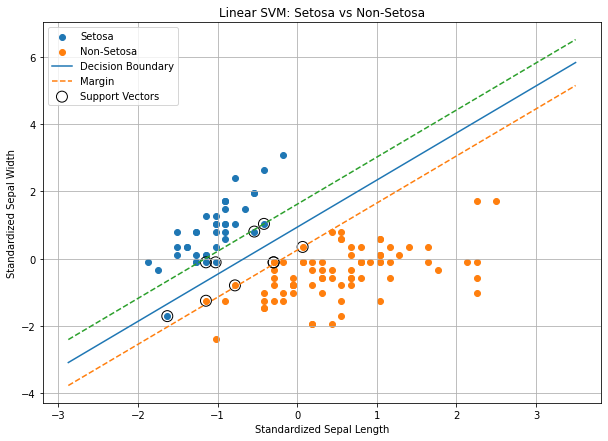

In [11]:
plt.figure(figsize=(10, 7))

# Plot training points
plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    label="Setosa"
)

plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    label="Non-Setosa"
)

# Range of x values
x_values = np.linspace(
    X_train_scaled[:, 0].min() - 1,
    X_train_scaled[:, 0].max() + 1,
    200
)

# Decision boundary
decision_boundary = -(w[0] * x_values + b) / w[1]

# Positive margin
margin_positive = -(w[0] * x_values + b - 1) / w[1]

# Negative margin
margin_negative = -(w[0] * x_values + b + 1) / w[1]

plt.plot(
    x_values,
    decision_boundary,
    label="Decision Boundary"
)

plt.plot(
    x_values,
    margin_positive,
    "--",
    label="Margin"
)

plt.plot(
    x_values,
    margin_negative,
    "--"
)

# Highlight support vectors
support_vectors = svm_model.support_vectors_

plt.scatter(
    support_vectors[:, 0],
    support_vectors[:, 1],
    s=120,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Standardized Sepal Length")
plt.ylabel("Standardized Sepal Width")
plt.title("Linear SVM: Setosa vs Non-Setosa")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
for C in [0.01, 0.1, 1, 10, 100]:

    model = SVC(kernel="linear", C=C)
    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    print(
        "C =", C,
        "Accuracy =", accuracy_score(y_test, prediction),
        "Support Vectors =", len(model.support_vectors_)
    )

C = 0.01 Accuracy = 1.0 Support Vectors = 80
C = 0.1 Accuracy = 1.0 Support Vectors = 31
C = 1 Accuracy = 1.0 Support Vectors = 10
C = 10 Accuracy = 1.0 Support Vectors = 4
C = 100 Accuracy = 1.0 Support Vectors = 3
